In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint



In [3]:
# -------------------------------
# PATHS
# -------------------------------
train_dir = r"D:\Chilli final dataset\augtrain"
val_dir   = r"D:\Chilli final dataset\val"
test_dir = r"D:\Chilli final dataset\test"

IMG_SIZE = 224
BATCH_SIZE = 32

# MixUp / CutMix parameters
MIXUP_ALPHA = 0.2
CUTMIX_ALPHA = 1.0
MIX_PROB = 0.5   # 50% MixUp, 50% CutMix

# -------------------------------
# 🔥 DATA AUGMENTATION
# -------------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    brightness_range=[0.7, 1.3],
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen_base = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False   # IMPORTANT for metrics
)

num_classes = train_gen_base.num_classes



Found 24000 images belonging to 3 classes.
Found 2207 images belonging to 3 classes.
Found 2207 images belonging to 3 classes.


In [4]:
# -------------------------------
# 🔥 MIXUP FUNCTION
# -------------------------------
def mixup(x1, y1, x2, y2, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    x = lam * x1 + (1 - lam) * x2
    y = lam * y1 + (1 - lam) * y2
    return x, y

# -------------------------------
# 🔥 CUTMIX FUNCTION
# -------------------------------
def cutmix(x1, y1, x2, y2, alpha=1.0):
    lam = np.random.beta(alpha, alpha)

    batch_size, h, w, c = x1.shape

    # Random box
    cx = np.random.randint(w)
    cy = np.random.randint(h)

    cut_w = int(w * np.sqrt(1 - lam))
    cut_h = int(h * np.sqrt(1 - lam))

    x1_copy = np.copy(x1)

    x1_copy[:, 
            max(cy - cut_h // 2, 0):min(cy + cut_h // 2, h),
            max(cx - cut_w // 2, 0):min(cx + cut_w // 2, w), :] = \
    x2[:, 
        max(cy - cut_h // 2, 0):min(cy + cut_h // 2, h),
        max(cx - cut_w // 2, 0):min(cx + cut_w // 2, w), :]

    lam_adjusted = 1 - (cut_w * cut_h) / (w * h)
    y = lam_adjusted * y1 + (1 - lam_adjusted) * y2

    return x1_copy, y

# -------------------------------
# 🔥 COMBINED GENERATOR
# -------------------------------
def mix_generator(generator):
    while True:
        x1, y1 = next(generator)
        x2, y2 = next(generator)

        if np.random.rand() < MIX_PROB:
            x, y = mixup(x1, y1, x2, y2, MIXUP_ALPHA)
        else:
            x, y = cutmix(x1, y1, x2, y2, CUTMIX_ALPHA)

        yield x, y

train_gen = mix_generator(train_gen_base)



In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

IMG_SIZE = 224

# -------------------------------
# BASE MODEL (Custom CNN)
# -------------------------------
base_model = models.Sequential([
    
    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same',
                  input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    
    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    
    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    
    # Block 4 (deeper feature extraction)
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2))
])

# -------------------------------
# FULL MODEL (Same Head ✅)
# -------------------------------
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(
        256,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.01)
    ),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

# -------------------------------
# COMPILE
# -------------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_2 (Sequential)   (None, 14, 14, 256)       390336    
                                                                 
 global_average_pooling2d_1  (None, 256)               0         
  (GlobalAveragePooling2D)                                       
                                                                 
 batch_normalization_9 (Bat  (None, 256)               1024      
 chNormalization)                                                
                                                                 
 dense_2 (Dense)             (None, 256)               65792     
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_3 (Dense)             (None, 3)                

In [7]:
# -------------------------------
# CALLBACKS
# -------------------------------
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6),
    ModelCheckpoint("CustomCNNchilli_best_model.h5", monitor='val_loss', save_best_only=True)
]
steps_per_epoch = train_gen_base.samples // BATCH_SIZE

# -------------------------------
# 🚀 PHASE 1 TRAINING
# -------------------------------
history1 = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    epochs=25,
    callbacks=callbacks
)

Epoch 1/25


750/750 [==============================] - 1730s 2s/step - loss: 1.3808 - accuracy: 0.7423 - val_loss: 1.1058 - val_accuracy: 0.5446 - lr: 0.0010
Epoch 2/25


C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


750/750 [==============================] - 1435s 2s/step - loss: 0.6308 - accuracy: 0.8126 - val_loss: 0.9778 - val_accuracy: 0.5165 - lr: 0.0010
Epoch 3/25
750/750 [==============================] - 1432s 2s/step - loss: 0.5886 - accuracy: 0.8358 - val_loss: 1.1979 - val_accuracy: 0.4816 - lr: 0.0010
Epoch 4/25
750/750 [==============================] - 1432s 2s/step - loss: 0.5796 - accuracy: 0.8395 - val_loss: 1.0974 - val_accuracy: 0.5088 - lr: 0.0010
Epoch 5/25
750/750 [==============================] - 1431s 2s/step - loss: 0.5526 - accuracy: 0.8545 - val_loss: 1.4455 - val_accuracy: 0.5138 - lr: 0.0010
Epoch 6/25
750/750 [==============================] - 1554s 2s/step - loss: 0.5015 - accuracy: 0.8725 - val_loss: 0.9591 - val_accuracy: 0.5981 - lr: 3.0000e-04
Epoch 7/25
750/750 [==============================] - 1519s 2s/step - loss: 0.4825 - accuracy: 0.8767 - val_loss: 0.8590 - val_accuracy: 0.6570 - lr: 3.0000e-04
Epoch 8/25
750/750 [==============================] - 1472s 2

In [8]:
# -------------------------------
# 📊 FINAL RESULT (VAL + TEST)
# -------------------------------
val_loss, val_acc = model.evaluate(val_gen)
print(f"\n✅ Final Validation Accuracy: {val_acc * 100:.2f}%")

test_loss, test_acc = model.evaluate(test_gen)
print(f"✅ Final Test Accuracy: {test_acc * 100:.2f}%")

69/69 [==============================] - 140s 2s/step - loss: 0.8087 - accuracy: 0.6760

✅ Final Validation Accuracy: 67.60%
69/69 [==============================] - 158s 2s/step - loss: 0.8356 - accuracy: 0.7010
✅ Final Test Accuracy: 70.10%


In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predictions
y_pred = model.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

# Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=test_gen.class_indices.keys()))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
print("\nConfusion Matrix:\n", cm)

69/69 [==============================] - 114s 2s/step

Classification Report:

                            precision    recall  f1-score   support

           Healthy control       0.80      0.94      0.86      1000
Initial Symptoms of ChiLCV       0.72      0.44      0.54       855
 Severe Symptoms of ChiLCV       0.46      0.68      0.55       352

                  accuracy                           0.70      2207
                 macro avg       0.66      0.68      0.65      2207
              weighted avg       0.71      0.70      0.69      2207


Confusion Matrix:
 [[937  42  21]
 [224 372 259]
 [ 11 103 238]]


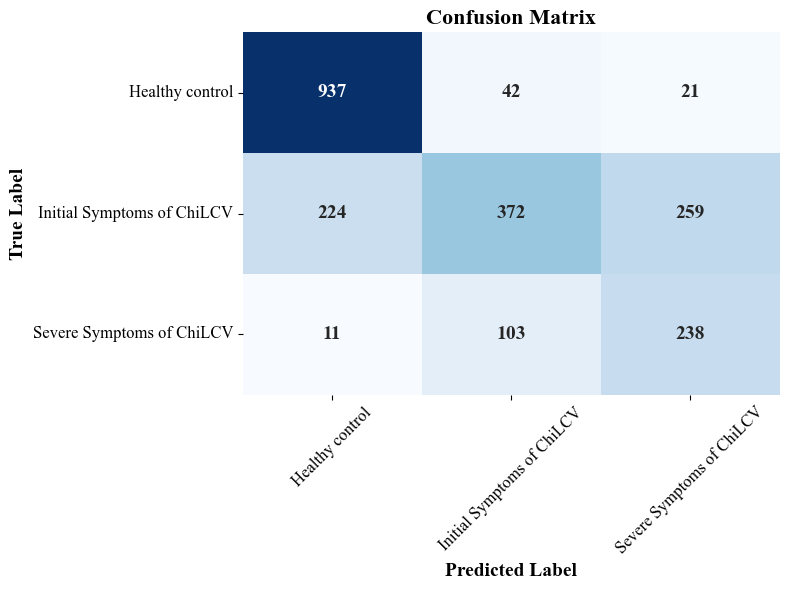

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ Get class names from your generator
class_names = list(test_gen.class_indices.keys())

plt.figure(figsize=(8,6))
plt.rcParams['font.family'] = 'Times New Roman'

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar=False,
            annot_kws={"size":14, "weight":"bold"})  # bigger & bold

plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=14, fontweight='bold')

plt.xticks(rotation=45, fontsize=12)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.savefig("confusion_matrix_heatmap.tiff", dpi=300)
plt.show()

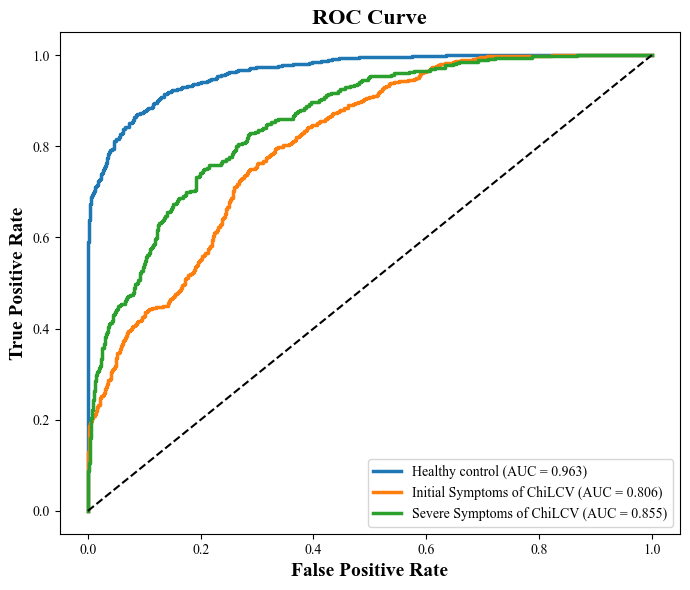

In [11]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Set Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

# Predictions (you already have y_pred, y_true)
num_classes = len(test_gen.class_indices)
class_names = list(test_gen.class_indices.keys())

# Binarize labels
y_true_bin = label_binarize(y_true, classes=range(num_classes))

plt.figure(figsize=(7,6))

# Plot ROC for each class
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, linewidth=2.5,
             label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

# Diagonal line
plt.plot([0,1], [0,1], 'k--', linewidth=1.5)

# Labels & title
plt.title('ROC Curve', fontsize=16, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')

plt.legend(fontsize=10)
plt.grid(False)

plt.tight_layout()
plt.savefig("roc_curve_Q1.tiff", dpi=300)
plt.show()

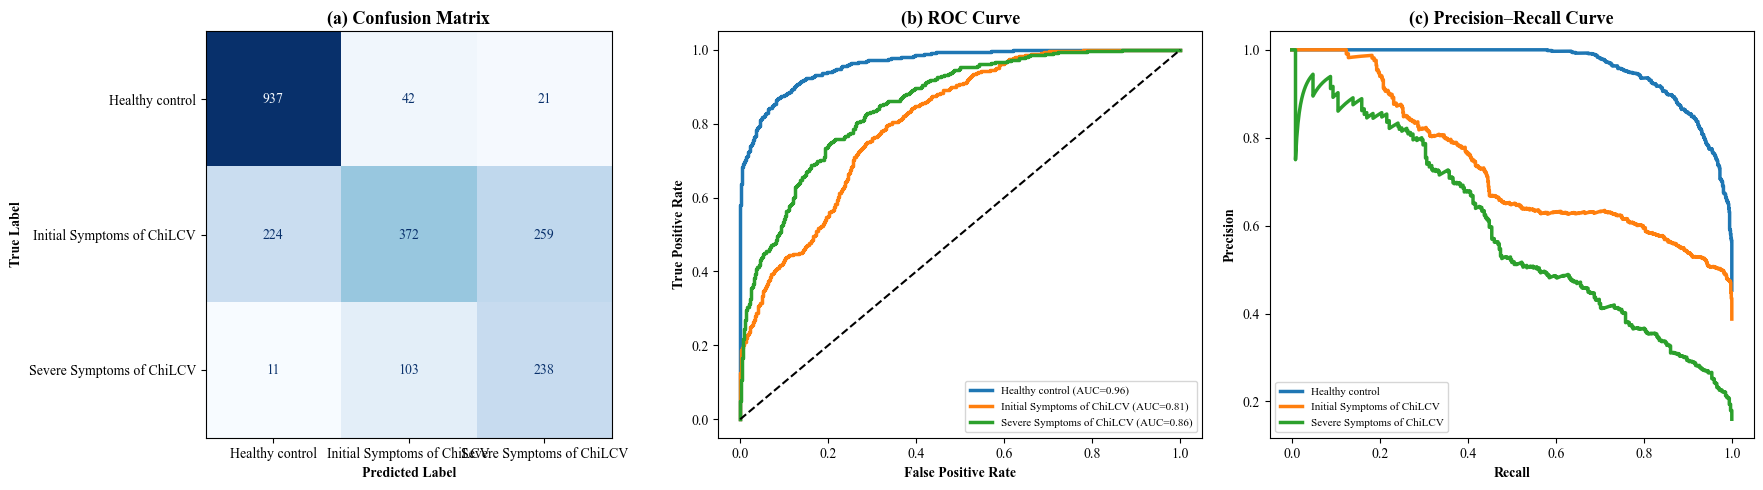

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize

# Set Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

# -------------------------------
# Predictions (already computed)
# -------------------------------
# y_pred = model.predict(test_gen)
# y_pred_classes = np.argmax(y_pred, axis=1)
# y_true = test_gen.classes

class_names = list(test_gen.class_indices.keys())
num_classes = len(class_names)

# Binarize labels
y_true_bin = label_binarize(y_true, classes=range(num_classes))

# -------------------------------
# Create figure
# -------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# ===============================
# (a) Confusion Matrix
# ===============================
cm = confusion_matrix(y_true, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)

axes[0].set_title('(a) Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontweight='bold')
axes[0].set_ylabel('True Label', fontweight='bold')

# ===============================
# (b) ROC Curve
# ===============================
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    
    axes[1].plot(fpr, tpr, linewidth=2.5,
                 label=f'{class_names[i]} (AUC={roc_auc:.2f})')

axes[1].plot([0,1], [0,1], 'k--', linewidth=1.5)
axes[1].set_title('(b) ROC Curve', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate', fontweight='bold')
axes[1].set_ylabel('True Positive Rate', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(False)

# ===============================
# (c) Precision-Recall Curve
# ===============================
for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_pred[:, i])
    
    axes[2].plot(recall, precision, linewidth=2.5,
                 label=class_names[i])

axes[2].set_title('(c) Precision–Recall Curve', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Recall', fontweight='bold')
axes[2].set_ylabel('Precision', fontweight='bold')
axes[2].legend(fontsize=8)
axes[2].grid(False)

# -------------------------------
# Final layout
# -------------------------------
plt.tight_layout()
plt.savefig("Fig_Combined_Performance_Q1.tiff", dpi=300)
plt.show()

In [17]:
import pickle

with open(r"D:\Chilli final dataset\CustomCNNchilli_history.pkl", "wb") as f:
    pickle.dump(history1.history, f)

In [ ]:
print(history.keys())

# Example:
train_acc = history['accuracy']
val_acc = history['val_accuracy']

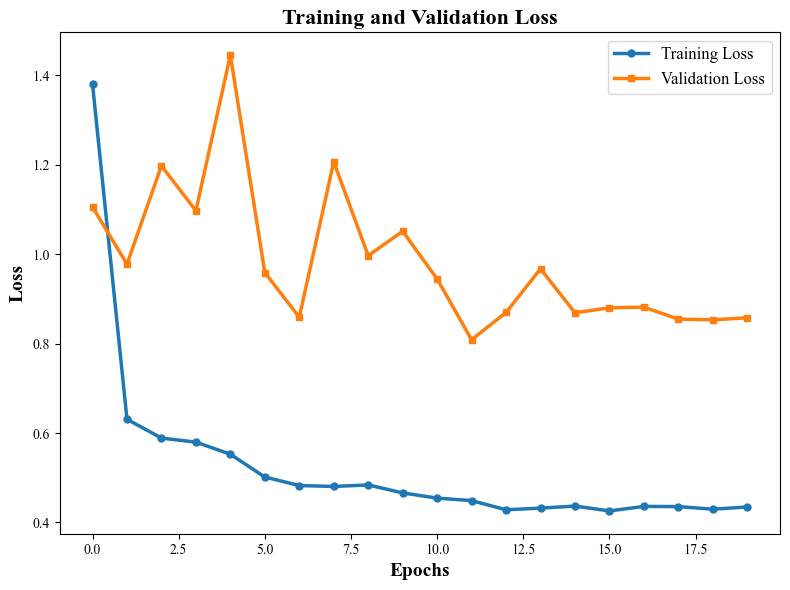

In [14]:
import matplotlib.pyplot as plt

# Set Times New Roman font
plt.rcParams['font.family'] = 'Times New Roman'

train_loss = history1.history['loss']
val_loss = history1.history['val_loss']

plt.figure(figsize=(8,6))

plt.plot(train_loss, marker='o', markersize=5, linewidth=2.5)
plt.plot(val_loss, marker='s', markersize=5, linewidth=2.5)

plt.title('Training and Validation Loss', fontsize=16, fontweight='bold')
plt.xlabel('Epochs', fontsize=14, fontweight='bold')
plt.ylabel('Loss', fontsize=14, fontweight='bold')

plt.legend(['Training Loss', 'Validation Loss'], fontsize=12)

plt.grid(False)
plt.tight_layout()

plt.savefig("loss_plot.tiff", dpi=300)
plt.show()

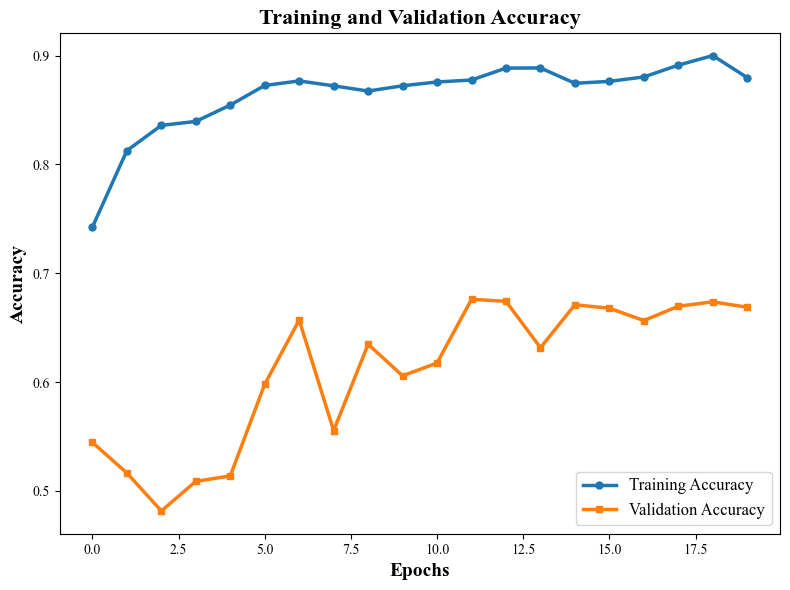

In [15]:
train_acc = history1.history['accuracy']
val_acc = history1.history['val_accuracy']

plt.figure(figsize=(8,6))

plt.plot(train_acc, marker='o', markersize=5, linewidth=2.5)
plt.plot(val_acc, marker='s', markersize=5, linewidth=2.5)

plt.title('Training and Validation Accuracy', fontsize=16, fontweight='bold')
plt.xlabel('Epochs', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=14, fontweight='bold')

plt.legend(['Training Accuracy', 'Validation Accuracy'], fontsize=12)

plt.grid(False)
plt.tight_layout()

plt.savefig("accuracy_plot.tiff", dpi=300)
plt.show()

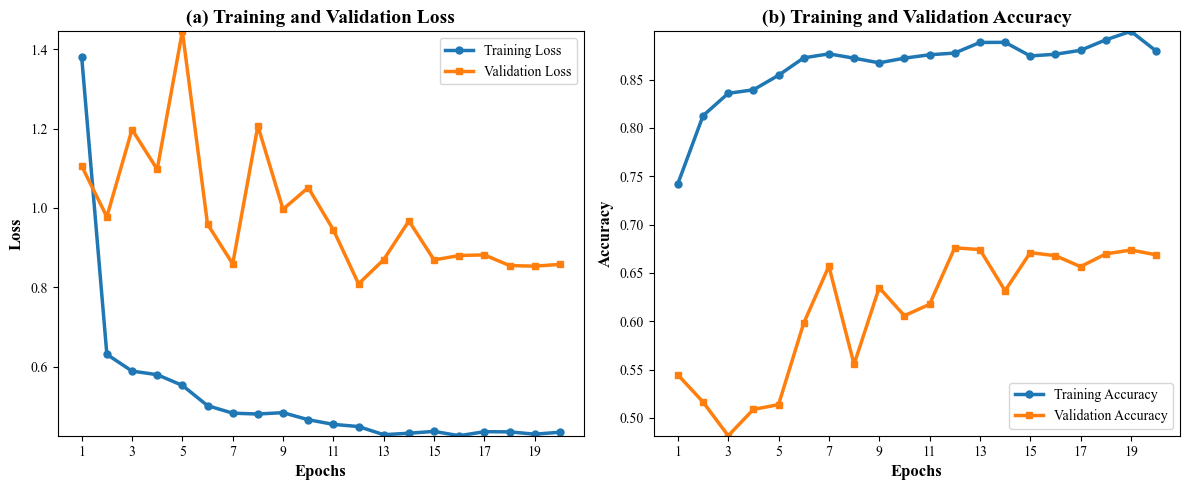

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Set Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

# Extract data
train_loss = history1.history['loss']
val_loss = history1.history['val_loss']
train_acc = history1.history['accuracy']
val_acc = history1.history['val_accuracy']

epochs = range(1, len(train_loss) + 1)

# -------------------------------
# Set consistent limits
# -------------------------------
loss_min = min(min(train_loss), min(val_loss))
loss_max = max(max(train_loss), max(val_loss))

acc_min = min(min(train_acc), min(val_acc))
acc_max = max(max(train_acc), max(val_acc))

# -------------------------------
# Create subplots
# -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Common x-ticks (every 2 epochs)
xticks = np.arange(1, len(epochs)+1, 2)

# -------------------------------
# (a) Loss Plot
# -------------------------------
axes[0].plot(epochs, train_loss, marker='o', markersize=5, linewidth=2.5)
axes[0].plot(epochs, val_loss, marker='s', markersize=5, linewidth=2.5)

axes[0].set_title('(a) Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loss', fontsize=12, fontweight='bold')

axes[0].set_xticks(xticks)
axes[0].set_ylim([loss_min, loss_max])

axes[0].legend(['Training Loss', 'Validation Loss'], fontsize=10)
axes[0].grid(False)

# -------------------------------
# (b) Accuracy Plot
# -------------------------------
axes[1].plot(epochs, train_acc, marker='o', markersize=5, linewidth=2.5)
axes[1].plot(epochs, val_acc, marker='s', markersize=5, linewidth=2.5)

axes[1].set_title('(b) Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epochs', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy', fontsize=12, fontweight='bold')

axes[1].set_xticks(xticks)
axes[1].set_ylim([acc_min, acc_max])

axes[1].legend(['Training Accuracy', 'Validation Accuracy'], fontsize=10)
axes[1].grid(False)

# Layout
plt.tight_layout()

# Save
plt.savefig("Fig5_final_Q1.tiff", dpi=300)

plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

# -------------------------------
# Get last conv layer
# -------------------------------
def get_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name

last_conv_layer_name = get_last_conv_layer(model)

# -------------------------------
# Grad-CAM function
# -------------------------------
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

In [ ]:
def display_gradcam(img_path, model, last_conv_layer_name):
    
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224,224))
    img_array = np.expand_dims(img/255.0, axis=0)

    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    return img, superimposed_img

In [ ]:
plt.rcParams['font.family'] = 'Times New Roman'

# Example images (replace with your dataset paths)
image_paths = [
    r"D:\test\healthy1.jpg",
    r"D:\test\initial1.jpg",
    r"D:\test\severe1.jpg"
]

titles = ['(a) Healthy', '(b) Initial Stage', '(c) Severe Stage']

fig, axes = plt.subplots(1, 3, figsize=(12,4))

for i, img_path in enumerate(image_paths):
    original, gradcam = display_gradcam(img_path, model, last_conv_layer_name)
    
    axes[i].imshow(cv2.cvtColor(gradcam, cv2.COLOR_BGR2RGB))
    axes[i].set_title(titles[i], fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig("Fig_GradCAM.tiff", dpi=300)
plt.show()